# ****EV Price Predictor****

## ***CELL 1. SETUP***

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.append(os.path.join(os.getcwd(), "..", "src"))

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from data_loader import DataLoader
from feature_engineering import FeatureEngineering
from preprocessing import Preprocessing
from train import Trainer

# Rebuild pipeline with same seed → identical encoders/scaler

loader = DataLoader(subfolder="raw")
loader.load("ev_market_2026.csv").validate()
df_raw = loader.get_df()

train_df, test_df = train_test_split(df_raw, test_size=0.2, random_state=42)

DROP_COLS = ["brand", "model"]

def apply_fe(df):
    fe = FeatureEngineering(df)
    return (fe.add_efficiency_features()
              .add_performance_score()
              .add_age_feature()
              .add_value_score()
              .get_df())

train_df = apply_fe(train_df).drop(columns=DROP_COLS, errors="ignore")
test_df  = apply_fe(test_df).drop(columns=DROP_COLS,  errors="ignore")

preprocessor = Preprocessing(train_df)
preprocessor.handling_missing_values()              .encoding(target_col="price_usd")              .scaling(target_col="price_usd")

train_clean = preprocessor.get_df()
test_clean  = preprocessor.transform(test_df)

trainer = Trainer(train_clean, test_clean, target_col="price_usd")
trainer.train_all()
model = trainer.get_best_model()

print("✅ Pipeline ready. Fill in Cell 2 and run Cell 3.")


2026-06-14 01:02:10 | INFO     | data_loader | DataLoader initialized | subfolder: raw
2026-06-14 01:02:10 | INFO     | data_loader | Loading file | path: c:\Users\mrcoo\OneDrive\Desktop\ev-price-prediction\data\raw\ev_market_2026.csv
2026-06-14 01:02:10 | INFO     | data_loader | file loaded successfully | shape: (2000, 24) | columns: ['brand', 'model', 'year', 'variant', 'price_usd', 'battery_capacity_kwh', 'range_miles', 'charging_speed_kw', 'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm', 'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft', 'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin', 'market_segment', 'annual_sales_units', 'customer_rating', 'warranty_years'] 
2026-06-14 01:02:10 | INFO     | data_loader | Running validation checks...
2026-06-14 01:02:10 | WARNING  | data_loader | Columns with missing values:
Series([], )
2026-06-14 01:02:10 | INFO     | data_loader | No duplicate rows found
2026-06-14 01:02:10 | INFO

## ***CELL 2. FILL IN THE EV DETAILS***

In [3]:
year                  = 2024          # 2020 – 2026
variant               = "Long Range"  # Base | Standard | Long Range | Performance | Premium
battery_capacity_kwh  = 82.0          # kWh  (40 – 120)
range_miles           = 310.0         # miles (150 – 447)
charging_speed_kw     = 170.0         # kW   (50 – 350)
acceleration_0_60_mph = 4.5           # seconds (2.5 – 8.0)  lower = faster
top_speed_mph         = 155.0         # mph  (118 – 200)
horsepower            = 450.0         # hp   (150 – 1000)
torque_nm             = 550.0         # Nm   (200 – 988)
drive_type            = "AWD"         # AWD | FWD | RWD
seating_capacity      = 5             # 2 – 7
body_type             = "SUV"         # SUV | Sedan | Hatchback | Coupe | Truck | Van
cargo_volume_cubic_ft = 40.0          # ft³  (15 – 80)
weight_kg             = 2000.0        # kg   (1500 – 3000)
safety_rating         = 5             # 3 | 4 | 5
autopilot_level       = 2             # 0 | 1 | 2 | 3
country_of_origin     = "US"          # US | Germany | China | South Korea | Japan | Sweden
market_segment        = "Premium"     # Budget | Mid-range | Premium | Luxury
annual_sales_units    = 80000         # units sold per year (656 – 499717)
customer_rating       = 4.2           # 3.0 – 4.51
warranty_years        = 8             # years (3 – 8)

print("Values set. Run Cell 3 to predict ▶")


Values set. Run Cell 3 to predict ▶


## ***CELL 3. PREDICT***

In [4]:
# ── Build a raw row exactly like a row from the dataset ──────────────────
raw_input = pd.DataFrame([{
    "year":                  year,
    "variant":               variant,
    "battery_capacity_kwh":  battery_capacity_kwh,
    "range_miles":           range_miles,
    "charging_speed_kw":     charging_speed_kw,
    "acceleration_0_60_mph": acceleration_0_60_mph,
    "top_speed_mph":         top_speed_mph,
    "horsepower":            horsepower,
    "torque_nm":             torque_nm,
    "drive_type":            drive_type,
    "seating_capacity":      seating_capacity,
    "body_type":             body_type,
    "cargo_volume_cubic_ft": cargo_volume_cubic_ft,
    "weight_kg":             weight_kg,
    "safety_rating":         safety_rating,
    "autopilot_level":       autopilot_level,
    "country_of_origin":     country_of_origin,
    "market_segment":        market_segment,
    "annual_sales_units":    annual_sales_units,
    "customer_rating":       customer_rating,
    "warranty_years":        warranty_years,
    # price_usd not needed — that's what we're predicting
    # brand / model are dropped in the pipeline
}])

# Apply feature engineering 
# We set price_usd = 0 temporarily so FeatureEngineering.add_value_score()
# doesn't crash (it divides range_miles / price_usd). We drop it after.
raw_input["price_usd"] = 1  # placeholder — not used in prediction

fe = FeatureEngineering(raw_input)
input_fe = (fe.add_efficiency_features()
              .add_performance_score()
              .add_age_feature()
              .add_value_score()
              .get_df())

input_fe = input_fe.drop(columns=["price_usd"], errors="ignore")

# Apply preprocessing (transform only — no refit) 
input_processed = preprocessor.transform(input_fe)

# Drop target if it somehow appears
input_processed = input_processed.drop(columns=["price_usd"], errors="ignore")

# Align columns to match training feature order
expected_cols = train_clean.drop(columns=["price_usd"]).columns.tolist()
for col in expected_cols:
    if col not in input_processed.columns:
        input_processed[col] = 0
input_processed = input_processed[expected_cols]

# Predict 
predicted_price = model.predict(input_processed)[0]

# Display result 
print("=" * 48)
print("         EV PRICE PREDICTION RESULT")
print("=" * 48)
print(f"  Predicted price  :  ${predicted_price:>12,.2f} USD")
print("-" * 48)
print(f"  Body type        :  {body_type}")
print(f"  Variant          :  {variant}")
print(f"  Drive type       :  {drive_type}")
print(f"  Battery          :  {battery_capacity_kwh} kWh")
print(f"  Range            :  {range_miles} miles")
print(f"  Horsepower       :  {horsepower} hp")
print(f"  0-60 mph         :  {acceleration_0_60_mph}s")
print(f"  Market segment   :  {market_segment}")
print("=" * 48)


2026-06-14 01:06:58 | INFO     | feature_engineering | FeatureEngineering initialized | shape: (1, 22)
2026-06-14 01:06:58 | INFO     | feature_engineering | Adding efficiency features...
2026-06-14 01:06:58 | INFO     | feature_engineering | Adding performance score...
2026-06-14 01:06:58 | INFO     | feature_engineering | Adding vehicle age feature...
2026-06-14 01:06:58 | INFO     | feature_engineering | Adding value score feature...
2026-06-14 01:06:58 | INFO     | feature_engineering | Returning feature-engineered dataframe | shape: (1, 27)
2026-06-14 01:06:58 | INFO     | feature_engineering | New features added: ['range_per_kwh', 'charge_rate', 'performance_score', 'vehicle_age', 'value_score']
2026-06-14 01:06:58 | INFO     | preprocessing | Transforming new data | input shape: (1, 26)
2026-06-14 01:06:58 | INFO     | preprocessing | Scaling applied | 35 columns scaled
2026-06-14 01:06:58 | INFO     | preprocessing | Transform complete | output shape: (1, 35)
         EV PRICE 

## ***CELL 4. COMPARE MULTIPLE CONFIGURATIONS***
**HOW CHANGING BATTERY OR VARIANT AFFECTS PRICE**

2026-06-14 01:09:05 | INFO     | feature_engineering | FeatureEngineering initialized | shape: (1, 22)
2026-06-14 01:09:05 | INFO     | feature_engineering | Adding efficiency features...
2026-06-14 01:09:05 | INFO     | feature_engineering | Adding performance score...
2026-06-14 01:09:05 | INFO     | feature_engineering | Adding vehicle age feature...
2026-06-14 01:09:05 | INFO     | feature_engineering | Adding value score feature...
2026-06-14 01:09:05 | INFO     | feature_engineering | Returning feature-engineered dataframe | shape: (1, 27)
2026-06-14 01:09:05 | INFO     | feature_engineering | New features added: ['range_per_kwh', 'charge_rate', 'performance_score', 'vehicle_age', 'value_score']
2026-06-14 01:09:05 | INFO     | preprocessing | Transforming new data | input shape: (1, 26)
2026-06-14 01:09:05 | INFO     | preprocessing | Scaling applied | 35 columns scaled
2026-06-14 01:09:05 | INFO     | preprocessing | Transform complete | output shape: (1, 35)
2026-06-14 01:09:0

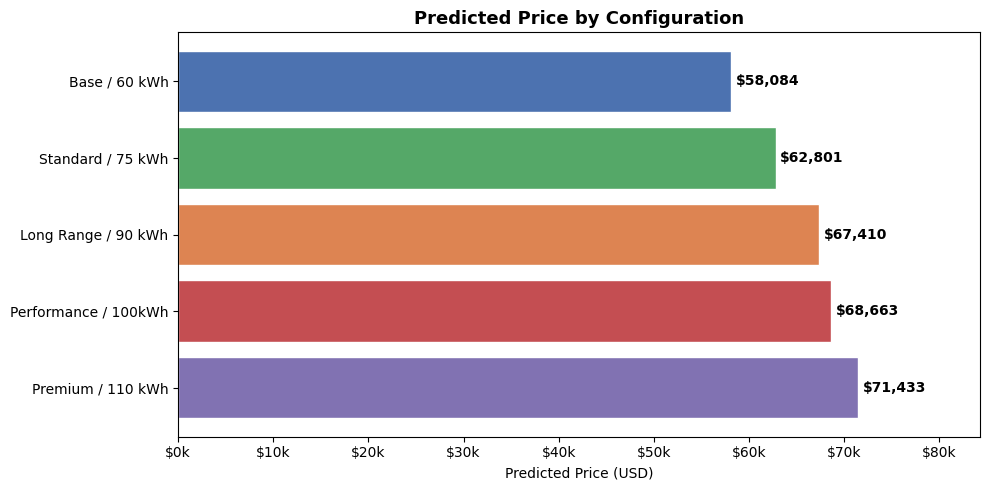

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

configs = [
    {"label": "Base / 60 kWh",       "variant": "Base",        "battery_capacity_kwh": 60,  "range_miles": 200, "horsepower": 250, "charging_speed_kw": 100},
    {"label": "Standard / 75 kWh",   "variant": "Standard",    "battery_capacity_kwh": 75,  "range_miles": 260, "horsepower": 350, "charging_speed_kw": 150},
    {"label": "Long Range / 90 kWh", "variant": "Long Range",  "battery_capacity_kwh": 90,  "range_miles": 340, "horsepower": 450, "charging_speed_kw": 200},
    {"label": "Performance / 100kWh","variant": "Performance",  "battery_capacity_kwh": 100, "range_miles": 380, "horsepower": 670, "charging_speed_kw": 270},
    {"label": "Premium / 110 kWh",   "variant": "Premium",     "battery_capacity_kwh": 110, "range_miles": 420, "horsepower": 800, "charging_speed_kw": 300},
]

# Shared fields (same as Cell 2 — edit if needed)
shared = {
    "year": year, "drive_type": drive_type, "body_type": body_type,
    "market_segment": market_segment, "country_of_origin": country_of_origin,
    "acceleration_0_60_mph": acceleration_0_60_mph, "top_speed_mph": top_speed_mph,
    "torque_nm": torque_nm, "seating_capacity": seating_capacity,
    "cargo_volume_cubic_ft": cargo_volume_cubic_ft, "weight_kg": weight_kg,
    "safety_rating": safety_rating, "autopilot_level": autopilot_level,
    "annual_sales_units": annual_sales_units, "customer_rating": customer_rating,
    "warranty_years": warranty_years, "price_usd": 1,
}

results = []
for cfg in configs:
    row = {**shared, **{k: v for k, v in cfg.items() if k != "label"}}
    df_row = pd.DataFrame([row])
    fe_row = FeatureEngineering(df_row)
    fe_out = (fe_row.add_efficiency_features()
                    .add_performance_score()
                    .add_age_feature()
                    .add_value_score()
                    .get_df()
                    .drop(columns=["price_usd"], errors="ignore"))
    proc = preprocessor.transform(fe_out)
    proc = proc.drop(columns=["price_usd"], errors="ignore")
    for col in expected_cols:
        if col not in proc.columns:
            proc[col] = 0
    proc = proc[expected_cols]
    price = model.predict(proc)[0]
    results.append({"Configuration": cfg["label"], "Predicted Price (USD)": round(price, 2)})

results_df = pd.DataFrame(results)

# ── Table ─────────────────────────────────────────────────────────────────
print(results_df.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B2"]
bars = ax.barh(results_df["Configuration"],
               results_df["Predicted Price (USD)"],
               color=colors, edgecolor="white")

for bar, val in zip(bars, results_df["Predicted Price (USD)"]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Predicted Price (USD)")
ax.set_title("Predicted Price by Configuration", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlim(0, results_df["Predicted Price (USD)"].max() * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/config_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
